### Worked example on admission data

#### 0. Read spreadsheets
Let us start with a brand new R session. Download the data file(s) onto your working directory. To see your current working directory, type <code>getwd()</code> in R. To change it, use <code>setwd()</code> with your intended path inside the brackets. You can also click Files->Change dir in base R. 

We then use <code>read.csv()</code> to read in a csv spreadsheet, or <code>read.table()</code> for text-only (e.g. tab-separated) tables. 

First to import is the discharge spreadsheet. After loading it into R, it is no longer a csv file but an R object. An object is created, a name given, as indicated by the arrow. The first line of code reads as "I am importing Discharge.csv into my current R session, and I call it Discharge hereafter. ". 

With the discharge data imported I can look up its column (variable) names, number of rows, etc. There are built-in functions for most operations. 

In [1]:
# READ DISCHARGE SPREADSHEET
Discharge<-read.csv('Discharge.csv', header=T)
# DISPLAY VARIABLE NAMES
names(Discharge)
# DISPLAY DIMENSION OF THE DATA
dim(Discharge)
# SHOW THE FIRST FEW ROWS (HEAD) OF THE DATA
head(Discharge)

[1] "Discharge.Ward"         "Admission.Date"         "Discharge.Date"        
[4] "Spell.LOS"              "Hospital.Number"        "Discharge.Spell.Number"

[1] 1807    6

,Discharge.Ward,Admission.Date,Discharge.Date,Spell.LOS,Hospital.Number,Discharge.Spell.Number
,<chr>,<chr>,<chr>,<int>,<int>,<chr>
1,T1,May-24,May-24,3,10000001,S0000001
2,W2,Dec-25,Dec-25,5,10000013,S0000013
3,T8,Aug-25,Aug-25,15,10000015,S0000017
4,W5,Jul-25,Jul-25,0,10000017,S0000018
5,W5,Dec-24,Dec-24,0,10000018,S0000019
6,W4,May-24,May-24,4,10000053,S0000056


Remember square brackets are for subsetting. For example, if I want to extracat the first column, I use <code>Discharge[,1]</code>. Another way is to call the column by name, like <code>Discharge$Discharge.Ward</code> with the dollar sign. 

Similarly, we can extract the first row by calling <code>Discharge[1,]</code>, and the first and third row together by <code>Discharge[c(1,3),]</code>. Since a data frame like this contains both rows and columns (2-dimensional), we have two indices inside the square brackets, i.e. <code>[row_id, column_id]</code>), separated by a comma. 

#### 1. Data pre-processing
Data pre-processing may include a collection of operations such as data cleansing, merging, recoding/reordering etc. In this example, we would like to import the admission data alongside discharge, then merge the two by a "key". Next we will remove columns that are redundant, and recode disease into two major types. 

Below illustrates a typical workflow of data pre-processing. Note that there are always multiple ways to tackle the same problem - but some are more elegant :-)

##### 1.1 Merge Discharge Ward into Admission
Import Admission.csv to the same R session. Now we would like to add an additional column to it to indicate <code>Discharge.Ward</code>, a variable available only from anoter dataset. Such procedure is called merging, and the function in R is <code>merge()</code>. There are several considerations: 1) The "key" is <code>Spell.Number</code> from admission data, which corresponds to <code>Discharge.Spell.Number</code> in discharge data), 2) we only need <code>Discharge.Ward</code> from dischage data, and 3) that we want to remove records (rows) with no match. 

Every functions in R comes with its help page by calling "?" before the function name. For instance, <code>?merge</code> will guide you to its manual. 

In [2]:
# SIMILARLY READ ADMISSION SPREADSHEET
Admission<-read.csv('Admission.csv', header=T)
# DISPLAY VARIABLE NAMES
names(Admission)
# DISPLAY DIMENSION OF THE DATA
dim(Admission)
# SHOW THE FIRST FEW ROWS (HEAD) OF THE DATA
head(Admission)

[1] "Division"          "Admission.Ward"    "Admission.Date"   
[4] "Discharged.Date"   "Spell.LOS"         "Primary.Diagnosis"
[7] "Post.Code"         "Hospital.Number"   "Spell.Number"

[1] 1610    9

,Division,Admission.Ward,Admission.Date,Discharged.Date,Spell.LOS,Primary.Diagnosis,Post.Code,Hospital.Number,Spell.Number
,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<int>,<chr>
1,Surgery and Cancer,W1,08/2025,08/2025,0,D570 - Sickle-cell anaemia with crisis,HA0,10000155,S0002909
2,Surgery and Cancer,W1,01/2026,02/2026,4,D570 - Sickle-cell anaemia with crisis,NW10,10000209,S0001112
3,Surgery and Cancer,W1,01/2026,01/2026,0,D570 - Sickle-cell anaemia with crisis,TW8,10000010,S0002945
4,Surgery and Cancer,W1,01/2026,01/2026,2,D570 - Sickle-cell anaemia with crisis,NW10,10000182,S0001111
5,Surgery and Cancer,W1,01/2026,01/2026,4,D570 - Sickle-cell anaemia with crisis,W10,10000448,S0001110
6,Surgery and Cancer,W1,01/2026,02/2026,10,D570 - Sickle-cell anaemia with crisis,HA9,10000184,S0001109


In [3]:
# MERGE Discharge.Ward TO ADMISSION DATA
# by.x= AND by.y ARE THE COLUMN NAMES OF THE KEYS FOR MERGING THE TWO DATASETS
# all.x=FALSE TO REMOVE ROWS WITH NO MATCH
# NOTE THAT I ONLY NEED TO FIRST AND SIXTH COLUMN FROM Discharge
Admission_with_Discharge<-merge(Admission, Discharge[,c(1,6)], 
                                by.x='Spell.Number', by.y='Discharge.Spell.Number', 
                                all.x=FALSE, sort=FALSE)
dim(Admission_with_Discharge)
head(Admission_with_Discharge)

[1] 1606   10

,Spell.Number,Division,Admission.Ward,Admission.Date,Discharged.Date,Spell.LOS,Primary.Diagnosis,Post.Code,Hospital.Number,Discharge.Ward
,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<int>,<chr>
1,S0002909,Surgery and Cancer,W1,08/2025,08/2025,0,D570 - Sickle-cell anaemia with crisis,HA0,10000155,W1
2,S0001112,Surgery and Cancer,W1,01/2026,02/2026,4,D570 - Sickle-cell anaemia with crisis,NW10,10000209,W2
3,S0002945,Surgery and Cancer,W1,01/2026,01/2026,0,D570 - Sickle-cell anaemia with crisis,TW8,10000010,W1
4,S0001111,Surgery and Cancer,W1,01/2026,01/2026,2,D570 - Sickle-cell anaemia with crisis,NW10,10000182,W2
5,S0001110,Surgery and Cancer,W1,01/2026,01/2026,4,D570 - Sickle-cell anaemia with crisis,W10,10000448,W2
6,S0001109,Surgery and Cancer,W1,01/2026,02/2026,10,D570 - Sickle-cell anaemia with crisis,HA9,10000184,W2


After merging <code>Discharge.Ward</code> into admission data, there are 1606 records retained. I save the results to a new R object (hence new object name). 

##### 1.2 Remove column(s)
For some reason I am not interested in <code>Division</code>. Again we use square brackets for subsetting, but this time with a minus sign to remove columns (or rows). Note that Division is the second column in this newly created data frame. 

In [4]:
# REMOVE COLUMN "Division", THE SECOND COLUMN
# REPLACE BY ITS OWN
Admission_with_Discharge<-Admission_with_Discharge[,-2]
head(Admission_with_Discharge)

,Spell.Number,Admission.Ward,Admission.Date,Discharged.Date,Spell.LOS,Primary.Diagnosis,Post.Code,Hospital.Number,Discharge.Ward
,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<int>,<chr>
1,S0002909,W1,08/2025,08/2025,0,D570 - Sickle-cell anaemia with crisis,HA0,10000155,W1
2,S0001112,W1,01/2026,02/2026,4,D570 - Sickle-cell anaemia with crisis,NW10,10000209,W2
3,S0002945,W1,01/2026,01/2026,0,D570 - Sickle-cell anaemia with crisis,TW8,10000010,W1
4,S0001111,W1,01/2026,01/2026,2,D570 - Sickle-cell anaemia with crisis,NW10,10000182,W2
5,S0001110,W1,01/2026,01/2026,4,D570 - Sickle-cell anaemia with crisis,W10,10000448,W2
6,S0001109,W1,01/2026,02/2026,10,D570 - Sickle-cell anaemia with crisis,HA9,10000184,W2


<code>Division</code> is gone! Now the data frame has 9 columns instead of 10. 

#### 1.3 Recode Diagnosis
The objective here is to recode disease into one of the two types: Sickle-cell and Thalassaemia, which can be inferred from the first four characters of <code>Primary.Diagnosis</code>. 

Therefore, it is a two-step process: first is to extract those four characters, then create a new variable, <code>Disease</code>, with the following definition: 
D570,D571,D572,D578=Sickle Cell
D561,D569=Thalassaemia

To extract the first four characters from <code>Primary.Diagnosis</code>, we use the substring operator <code>substr()</code>.  Then, I look at the disease code and decide which group it belongs to. The "belongs to" operator in R is <code>%in%</code> which return a boolean vector (of Trues and Falses). For instance: 

In [5]:
# CREATE A EMPTY COLUMN CALLED Disease WITHIN THE DATASET
Admission_with_Discharge$Disease<-NA

# EXTRACT THE FIRST FOUR CHARACTERS FROM Primary.Diagnosis, AND SAVE IT AS AN R OBJECT OUTSIDE OF THE DATASET
x<-substr(Admission_with_Discharge$Primary.Diagnosis, 1, 4)
head(x)

[1] "D570" "D570" "D570" "D570" "D570" "D570"

In [6]:
# IF x BELONGS TO D570, D571, D572, D578, THEY ARE SICKLE-CELL
Admission_with_Discharge$Disease[x %in% c('D570', 'D571', 'D572', 'D578')]<-'Sickle-cell'
Admission_with_Discharge$Disease[x %in% c('D561', 'D569')]<-'Thalassaemia'
head(Admission_with_Discharge)

,Spell.Number,Admission.Ward,Admission.Date,Discharged.Date,Spell.LOS,Primary.Diagnosis,Post.Code,Hospital.Number,Discharge.Ward,Disease
,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<int>,<chr>,<chr>
1,S0002909,W1,08/2025,08/2025,0,D570 - Sickle-cell anaemia with crisis,HA0,10000155,W1,Sickle-cell
2,S0001112,W1,01/2026,02/2026,4,D570 - Sickle-cell anaemia with crisis,NW10,10000209,W2,Sickle-cell
3,S0002945,W1,01/2026,01/2026,0,D570 - Sickle-cell anaemia with crisis,TW8,10000010,W1,Sickle-cell
4,S0001111,W1,01/2026,01/2026,2,D570 - Sickle-cell anaemia with crisis,NW10,10000182,W2,Sickle-cell
5,S0001110,W1,01/2026,01/2026,4,D570 - Sickle-cell anaemia with crisis,W10,10000448,W2,Sickle-cell
6,S0001109,W1,01/2026,02/2026,10,D570 - Sickle-cell anaemia with crisis,HA9,10000184,W2,Sickle-cell


Note that the variable <code>x</code> is defined outside of the data frame and is no-longer required (but it is still there!). R has a whole suite of functions for "regular expression" which allows you to perform text editing or mining given a certain pattern of text. 

### 2. Data analysis
It is important to realise each row is one admission, and this is the basic unit for our subsequent analyses. In some applications we may need to change the unit, for example, if the study is on patient level. 

#### 2.1 Descriptive statistics
Once the dataset is neat and tidy we can start analysing it by running some descriptive statistics. For example, the count under each category, mean/median/sd for continuous variables, etc. <code>table()</code> and <code>summary()</code> are particularly useful here. 

In [7]:
# ADMISSION WARD. CATEGORICAL
table(Admission_with_Discharge$Admission.Ward)


  W1 
1606 

In [8]:
# DISCHARGE WARD. CATEGORICAL
table(Admission_with_Discharge$Discharge.Ward)


T12 T17  W1  W2  W3  W4  W6 
  4   1 852 697  42   2   8 

In [9]:
# BASIC SUMMARY OF Spell.LOS. Spell.LOS ARE DAYS
summary(Admission_with_Discharge$Spell.LOS)
# OR CUSTOM QUANTILES, SAY 5% AND 95%
quantile(Admission_with_Discharge$Spell.LOS, c(0.05, 0.95))

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  0.000   0.000   1.000   3.849   6.000  70.000 

5% 95% 
  0  15

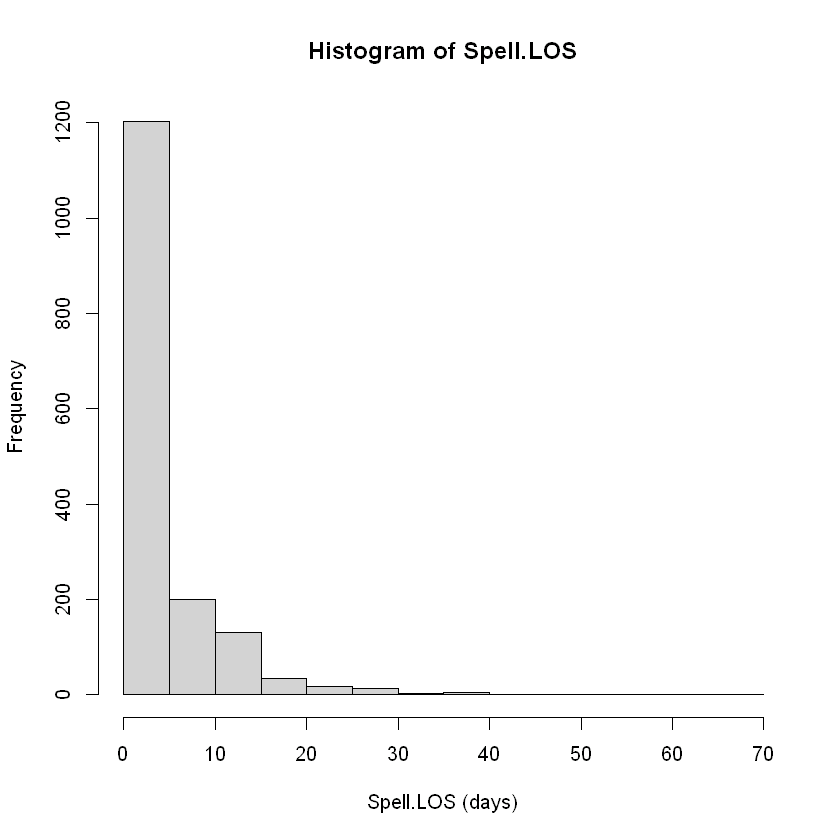

In [10]:
# HISTOGRAM, MORE ON PLOTS LATER
hist(Admission_with_Discharge$Spell.LOS, 
     main='Histogram of Spell.LOS', xlab='Spell.LOS (days)')

In [11]:
# Disease BY TYPE, CATEGORICAL
table(Admission_with_Discharge$Disease)


 Sickle-cell Thalassaemia 
        1601            5 

In [12]:
# CROSS TABULATION
table(Admission_with_Discharge$Disease, Admission_with_Discharge$Discharge.Ward)

              
               T12 T17  W1  W2  W3  W4  W6
  Sickle-cell    4   1 847 697  42   2   8
  Thalassaemia   0   0   5   0   0   0   0

The examples above demonstrated how easy summary tables are created for reporting. Further, cross tabulation allows us to visualise any association between two categorical variables. 

#### 2.2 Play around with dates
We have two dates in this dataset: <code>Admission.Date</code> and <code>Discharged.Date</code>, currently recognised as characters in R. R supports POSIX date format for date operations (e.g. count the number of days between two dates, work out the week of the day, etc), but I am not going to discussed here. Interested reader should consult <code>as.Date</code> for R's <code>Date</code> object type. 

A simpler alternative is to split our date variable into two as month and year, using <code>substr()</code> again. Below is my implementation to create four new variables associated with dates: 

In [13]:
# RECODE Date INTO Month AND Year IN TWO SEPARATE VARIABLES
# FIRST TWO CHARACTERS ARE MM, CHARACTERS 4-7 ARE YYYY. THEN CONVERT INTO NUMERIC
# Admission
Admission_with_Discharge$Admission.Month<-as.numeric(substr(Admission_with_Discharge$Admission.Date, 1, 2))
Admission_with_Discharge$Admission.Year<-as.numeric(substr(Admission_with_Discharge$Admission.Date, 4, 7))
# DO THE SAME FOR Discharged
Admission_with_Discharge$Discharged.Month<-as.numeric(substr(Admission_with_Discharge$Discharged.Date, 1, 2))
Admission_with_Discharge$Discharged.Year<-as.numeric(substr(Admission_with_Discharge$Discharged.Date, 4, 7))

You may view the data frame again but I'm confident enough that they are done properly. <code>as.numeric</code> is to turn characters into numbers. Note that <code>0</code> is a number, but <code>'0'</code> with a quote is a character. 

#### 2.3 More on dates. Financial year. 
Financial year is of some interest when money is involved. It can be inferred from <code>Admission.Year</code> and <code>Admission.Month</code> we just created, and if it belongs to the first three months we assign it to the previous financial year. A logical statement is needed here, and my choice is <code>ifelse</code>: 

In [14]:
# ADMISSION FINANCIAL YEAR?
Admission_with_Discharge$Financial.Year<-ifelse(
                                                Admission_with_Discharge$Admission.Month<=3, 
                                                Admission_with_Discharge$Admission.Year-1, 
                                                Admission_with_Discharge$Admission.Year)
# FIVE ADDITIONAL VARIABLES ON DATES ARE CREATED 
head(Admission_with_Discharge)

,Spell.Number,Admission.Ward,Admission.Date,Discharged.Date,Spell.LOS,Primary.Diagnosis,Post.Code,Hospital.Number,Discharge.Ward,Disease,Admission.Month,Admission.Year,Discharged.Month,Discharged.Year,Financial.Year
,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<int>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,S0002909,W1,08/2025,08/2025,0,D570 - Sickle-cell anaemia with crisis,HA0,10000155,W1,Sickle-cell,8,2025,8,2025,2025
2,S0001112,W1,01/2026,02/2026,4,D570 - Sickle-cell anaemia with crisis,NW10,10000209,W2,Sickle-cell,1,2026,2,2026,2025
3,S0002945,W1,01/2026,01/2026,0,D570 - Sickle-cell anaemia with crisis,TW8,10000010,W1,Sickle-cell,1,2026,1,2026,2025
4,S0001111,W1,01/2026,01/2026,2,D570 - Sickle-cell anaemia with crisis,NW10,10000182,W2,Sickle-cell,1,2026,1,2026,2025
5,S0001110,W1,01/2026,01/2026,4,D570 - Sickle-cell anaemia with crisis,W10,10000448,W2,Sickle-cell,1,2026,1,2026,2025
6,S0001109,W1,01/2026,02/2026,10,D570 - Sickle-cell anaemia with crisis,HA9,10000184,W2,Sickle-cell,1,2026,2,2026,2025


<code>ifelse()</code> takes three arguments. This first is the condition argument, if the condition is met, then it will return the second arugment, else (if the condition is false) it returns the third. 

#### 2.4 Number of discharged per month
Pivot tables can be created in almost no time in R. To report a summary statistic by category, we can use <code>by()</code>. I strongly encourage to look at its help page via <code>?by</code>. Generally it works like this: The first argument is the variable to be summarised, the second arugment is the "grouped by" variable, and in this case, per month, hence <code>Discharged.Month</code>, the third argument is the summary you want to calculate, here is simply <code>nrow()</code>. 

To put it into words, I am asking "How many rows of records are there per Discharge month?". 

In [15]:
# NUMBER OF DISCHARGED PER MONTH
by(Admission_with_Discharge, Admission_with_Discharge$Discharged.Month, nrow)

Admission_with_Discharge$Discharged.Month: 1
[1] 151
------------------------------------------------------------ 
Admission_with_Discharge$Discharged.Month: 2
[1] 59
------------------------------------------------------------ 
Admission_with_Discharge$Discharged.Month: 3
[1] 62
------------------------------------------------------------ 
Admission_with_Discharge$Discharged.Month: 4
[1] 114
------------------------------------------------------------ 
Admission_with_Discharge$Discharged.Month: 5
[1] 139
------------------------------------------------------------ 
Admission_with_Discharge$Discharged.Month: 6
[1] 152
------------------------------------------------------------ 
Admission_with_Discharge$Discharged.Month: 7
[1] 147
------------------------------------------------------------ 
Admission_with_Discharge$Discharged.Month: 8
[1] 148
------------------------------------------------------------ 
Admission_with_Discharge$Discharged.Month: 9
[1] 155
-----------------------------

Another statistic of interest is the number of admissions per financial year (leave as exercise). 

#### 2.5 Spell.LOS distribution per discharged month
Length of stay varies across admissions, and potentially across months. We can use <code>hist()</code> or <code>boxplot()</code> to visualise the distribution of LOS as previously demonstrated. 

Here my goal is to produce 12 boxplots, one for each discharged month, with just one line of command: 

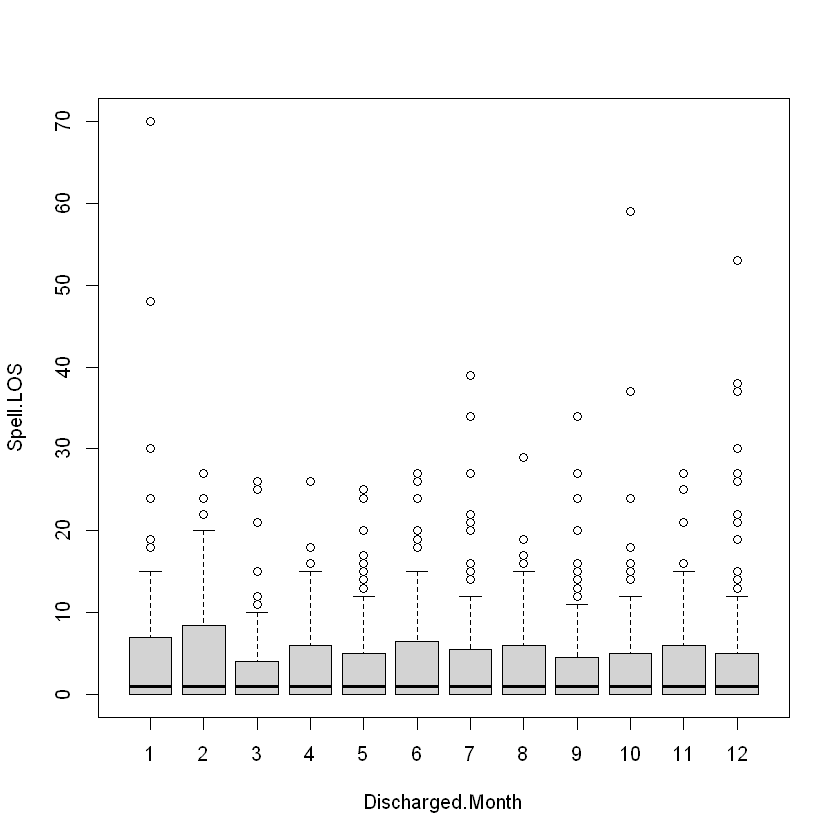

In [16]:
boxplot(Spell.LOS~Discharged.Month, data=Admission_with_Discharge)
#boxplot(Admission_with_Discharge$Spell.LOS~Admission_with_Discharge$Discharged.Month)

The <code>~</code> operator is very common in specifying formulae in linear models. There are additional commands for axis labels, font size, title, and many else. 

#### 2.5 Admissions with LOS>=21 days
Unfortunately some patients spent a long time at a hospital. We can subset those with LOS of 21 days or more. By subetting we mean to use the square bracket again with a logical condition:

In [17]:
# SUBSET THE DATA FRAME WHOSE Spell.LOS IS 21 OR MORE
y<-Admission_with_Discharge[Admission_with_Discharge$Spell.LOS>=21,]
dim(y)
head(y)

[1] 40 15

,Spell.Number,Admission.Ward,Admission.Date,Discharged.Date,Spell.LOS,Primary.Diagnosis,Post.Code,Hospital.Number,Discharge.Ward,Disease,Admission.Month,Admission.Year,Discharged.Month,Discharged.Year,Financial.Year
,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<int>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
27,S0001093,W1,10/2025,11/2025,25,D570 - Sickle-cell anaemia with crisis,UB8,10000442,W2,Sickle-cell,10,2025,11,2025,2025
74,S0000187,W1,06/2025,07/2025,34,D570 - Sickle-cell anaemia with crisis,HA0,10000155,W2,Sickle-cell,6,2025,7,2025,2025
78,S0000189,W1,11/2024,12/2024,21,D570 - Sickle-cell anaemia with crisis,HA0,10000155,W2,Sickle-cell,11,2024,12,2024,2024
82,S0000193,W1,06/2024,07/2024,21,D570 - Sickle-cell anaemia with crisis,HA0,10000155,W2,Sickle-cell,6,2024,7,2024,2024
130,S0000611,W1,01/2026,01/2026,24,D570 - Sickle-cell anaemia with crisis,SW6,10000316,W2,Sickle-cell,1,2026,1,2026,2025
225,S0000568,W1,11/2025,12/2025,27,D570 - Sickle-cell anaemia with crisis,SW3,10000307,W2,Sickle-cell,11,2025,12,2025,2025


There are 40 such admission. We can even make a pivot table to classify those admissions per financial year: 

In [18]:
by(y, y$Financial.Year, nrow)

y$Financial.Year: 2024
[1] 27
------------------------------------------------------------ 
y$Financial.Year: 2025
[1] 13

We can remove <code>y</code> by calling <code>rm(y)</code>. 

#### 2.6 Patient-level statistic: number of unique patients
So far all analyses have been on per admission basis. It is possible (very likely) that these admissions were made by the same patient. One useful question to know the number of unique patiets in this dataset. Patients can be uniquely identified by the <code>Hospital.Number</code> column: 

In [19]:
# NUMBER OF UNIQUE PATIENTS
length(unique(Admission_with_Discharge$Hospital.Number))

[1] 260

There are 260 unique patients. The <code>unique()</code> functions remove duplicates, and the <code>length()</code> of it is the number of unqiue patients. 

#### 2.7 Patient-level analysis: total bed time per patient
It makes sense to analyse each patient's total bed time across multiple admissions. We certainly need the <code>by()</code> function again, but it does not make sense to return all 260 total bed times as our brain cannot process this amount of information. We can plot a histogram on these 260 summaries instead: 

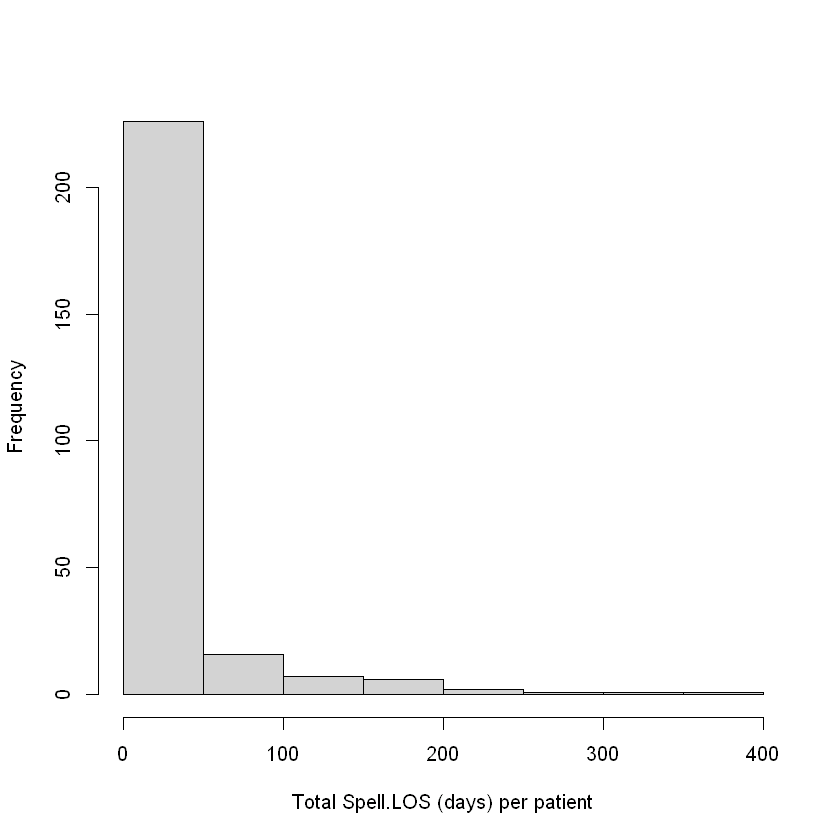

In [20]:
# TOTAL BED TIME FOR EACH PATIENT, TOTAL MEANS SUM
# YOU'RE FREE TO SPLIT COMMANDS INTO MULTIPLE LINES
# THEN A HISTOGRAM ON THE SUMMARY TABLE
hist(by(Admission_with_Discharge$Spell.LOS, 
   Admission_with_Discharge$Hospital.Number, 
   sum), xlab='Total Spell.LOS (days) per patient', main='')

It is a skewed distribution. I hope by now you understand how we can make admission-level and patient-level analyses in R. 

#### 2.7 Patient-level analysis: number of admissions, per patient per financial year
Now we analyse the number of admissions under two categorical variables. There are two ways to do it, via <code>by()</code> or <code>table()</code>. You can actually put multiple categorical variables into the second argument of <code>by()</code>, wrapped in a <code>list</code>. 

In [21]:
# I AM NOT SHOWING THE ENTIRE OUTPUT WITH 260 PATIENTS AND 2 FINANCIAL YEARS
x<-by(Admission_with_Discharge, 
       list(Admission_with_Discharge$Hospital.Number, Admission_with_Discharge$Financial.Year), 
       nrow)
head(x)

,2024,2025
10000002,31,58
10000010,36,92
10000013,4,7
10000017,8,13
10000032,1,NA
10000053,1,2


In [24]:
# EQUIVALENTLY I CAN USE table
y<-table(Admission_with_Discharge$Hospital.Number, Admission_with_Discharge$Financial.Year)
head(y)

          
           2024 2025
  10000002   31   58
  10000010   36   92
  10000013    4    7
  10000017    8   13
  10000032    1    0
  10000053    1    2

Generally, <code>by()</code> is more flexible. 

### 3. More plots
Apart from boxplots and histograms, base R has the capability to produce publishable-quality such as barplots, scatterplots, 3D contour plots, heatmaps, and many more. With external pacakges (choose wisely) you can even work with GIS for maps, and all sort of fancy graphics. 

#### 3.1 Bar char on admission, by month and by Discharge Ward

In [28]:
# COMPUTE THE PIVOT TABLE
x<-table(Admission_with_Discharge$Discharge.Ward, Admission_with_Discharge$Admission.Month)
x

     
       1  2  3  4  5  6  7  8  9 10 11 12
  T12  0  0  0  0  2  1  1  0  0  0  0  0
  T17  0  0  0  0  0  0  0  0  0  1  0  0
  W1  77 26 37 68 75 81 77 74 83 99 81 74
  W2  65 22 23 56 59 61 74 67 66 67 74 63
  W3   7  5  4  5  1  1  4  5  6  2  2  0
  W4   1  0  0  0  1  0  0  0  0  0  0  0
  W6   1  0  0  0  0  0  0  0  2  2  3  0

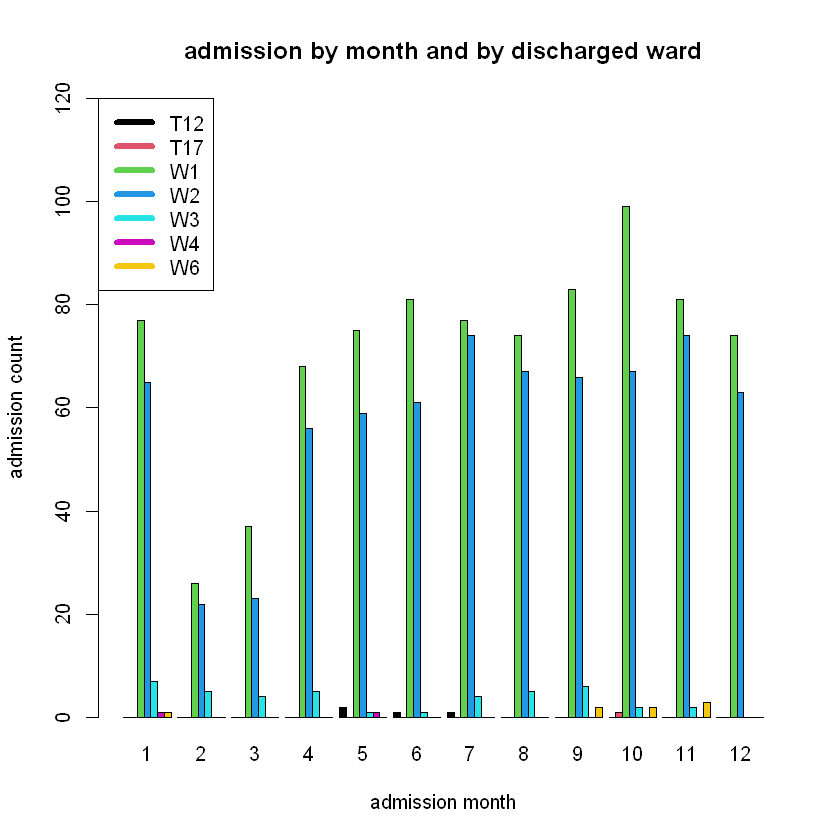

In [35]:
# PLOT
barplot(x, beside=TRUE, ylim=c(0, 120), col=1:7, 
        xlab='admission month', ylab='admission count', 
        main='admission by month and by discharged ward')
legend('topleft', legend=rownames(x), col=1:7, lty=1, lwd=5)

### 4. Hypothesis testing
Many questions can be asked given a dataset, and I believe the limit is our curiosity. For example, based on the boxplot above, I would like to know if <code>Spell.LOS</code> is the same across months. This is the spirit of hypothesis testing. 

I fit a negative binomial regression model, with <code>Spell.LOS</code> being the response, and <code>Discharge.Month</code> the explanatory variable. Note that it is a categorical variable with 12 levels. Then I can run an <code>anova()</code> to test for the significance. 

In [46]:
# IMPORT PACKAGE
require(MASS)
# FIT A NEGATIVE BINOMIAL REGRESSION FOR COUNTS
m<-glm.nb(Spell.LOS~as.factor(Discharged.Month), data=Admission_with_Discharge)
anova(m, test='LRT')

Warning message in anova.negbin(m, test = "LRT"):
"tests made without re-estimating 'theta'"


,Df,Deviance,Resid. Df,Resid. Dev,Pr(>Chi)
,<int>,<dbl>,<int>,<dbl>,<dbl>
NULL,NA,NA,1605,1622.663,NA
as.factor(Discharged.Month),11,7.376729,1594,1615.286,0.7678064


In [47]:
# MODEL SUMMARY
summary(m)


Call:
glm.nb(formula = Spell.LOS ~ as.factor(Discharged.Month), data = Admission_with_Discharge, 
    init.theta = 0.3690582406, link = log)

Coefficients:
                              Estimate Std. Error z value Pr(>|z|)    
(Intercept)                    1.53094    0.13920  10.998   <2e-16 ***
as.factor(Discharged.Month)2   0.08188    0.26207   0.312    0.755    
as.factor(Discharged.Month)3  -0.26445    0.26005  -1.017    0.309    
as.factor(Discharged.Month)4  -0.31130    0.21386  -1.456    0.145    
as.factor(Discharged.Month)5  -0.27510    0.20229  -1.360    0.174    
as.factor(Discharged.Month)6  -0.20918    0.19738  -1.060    0.289    
as.factor(Discharged.Month)7  -0.16874    0.19888  -0.848    0.396    
as.factor(Discharged.Month)8  -0.19310    0.19864  -0.972    0.331    
as.factor(Discharged.Month)9  -0.31861    0.19692  -1.618    0.106    
as.factor(Discharged.Month)10 -0.23683    0.19060  -1.243    0.214    
as.factor(Discharged.Month)11 -0.26510    0.19763  -1.341    0

Built-in tests include t-test, non-parametric rank-based tests, normality test, chi-square test for association, Fisher exact test, ... 